<a href="https://colab.research.google.com/github/nguyenminhtien31251023643/NguyenMinhTien.31251023643/blob/main/BaiTap1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import folium
coords = [10.761250869566194, 106.6686422003917]
m = folium.Map(location=coords, zoom_start=16)
folium.Marker(
    location=coords,
    popup="Đại học Kinh tế TP.HCM (UEH)",
).add_to(m)
folium.Marker(
    location=[10.755247166372847, 106.67079589730632],
    popup="Bệnh viện Nguyễn Tri Phương",
).add_to(m)
folium.Marker(
    location=[10.75862705779178, 106.66234374025903],
    popup="Bệnh viện Chợ Rẫy",
).add_to(m)
folium.Marker(
    location=[10.770914783553913, 106.67107418668157],
    popup="Trung Tâm Thương Mại Vạn Hạnh",
).add_to(m)
folium.Marker(
    location=[10.75375830946084, 106.66419527558479],
    popup="Miếu Bà Thiên Hậu",
).add_to(m)
folium.Marker(
    location=[10.758902089877147, 106.67352991290235],
    popup="Chợ An Đông",
).add_to(m)
folium.Marker(
    location=[10.761224110573343, 106.67263235162652],
    popup="Chùa Giác Ngộ",
).add_to(m)
m


In [ ]:
from geopy.distance import geodesic
import pandas as pd
import folium

locations = [
    ("Chợ Bến Thành", 10.772, 106.698),
    ("Nhà thờ Đức Bà", 10.780, 106.699),
    ("Dinh Độc Lập", 10.777, 106.695),
    ("Sân bay Tân Sơn Nhất", 10.818, 106.652),
    ("Landmark 81", 10.794, 106.721),
    ("Bến xe Miền Đông", 10.814, 106.710),
    ("Aeon Mall Tân Phú", 10.801, 106.618),
    ("ĐH Bách Khoa TP.HCM", 10.773, 106.660),
    ("Công viên Tao Đàn", 10.773, 106.691),
    ("Vincom Đồng Khởi", 10.779, 106.704)
]

center = (10.776, 106.700)

data = []
for name, lat, lon in locations:
    dist = geodesic(center, (lat, lon)).km
    data.append([name, lat, lon, dist])

df = pd.DataFrame(data, columns=["Tên", "Lat", "Lon", "Khoảng cách"])

m = folium.Map(location=center, zoom_start=12)

for _, row in df.iterrows():
    folium.Marker(
        location=[row["Lat"], row["Lon"]],
        popup=f'{row["Tên"]} - {row["Khoảng cách"]:.2f} km'
    ).add_to(m)

m


In [ ]:
import folium
from folium.plugins import HeatMap
import random

points = [[10.77 + random.uniform(-0.02,0.02), 106.70 + random.uniform(-0.02,0.02)] for _ in range(200)]

m = folium.Map(location=[10.776, 106.700], zoom_start=13)

HeatMap(points).add_to(m)

m


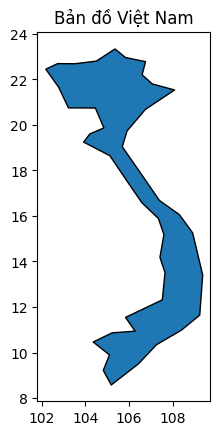

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Dùng dữ liệu online thay vì dataset cũ bị lỗi
url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries/VNM.geo.json"
gdf = gpd.read_file(url)

gdf.plot(edgecolor='black')

plt.title("Bản đồ Việt Nam")
plt.show()


In [ ]:
import osmnx as ox
import folium

center_point = (10.776, 106.700)

G = ox.graph_from_point(center_point, dist=3000, network_type='drive')

nodes = ox.graph_to_gdfs(G, edges=False)

m = folium.Map(location=center_point, zoom_start=13)

for _, node in nodes.iterrows():
    folium.CircleMarker(location=[node['y'], node['x']], radius=2).add_to(m)

m


In [ ]:
import numpy as np
import folium

customers = np.array([[10.77 + np.random.rand()/100, 106.70 + np.random.rand()/100] for _ in range(10)])
drivers = np.array([[10.77 + np.random.rand()/100, 106.70 + np.random.rand()/100] for _ in range(5)])

m = folium.Map(location=[10.776,106.700], zoom_start=13)

for c in customers:
    folium.Marker(location=c, icon=folium.Icon(color='blue')).add_to(m)

for d in drivers:
    folium.Marker(location=d, icon=folium.Icon(color='red')).add_to(m)

m


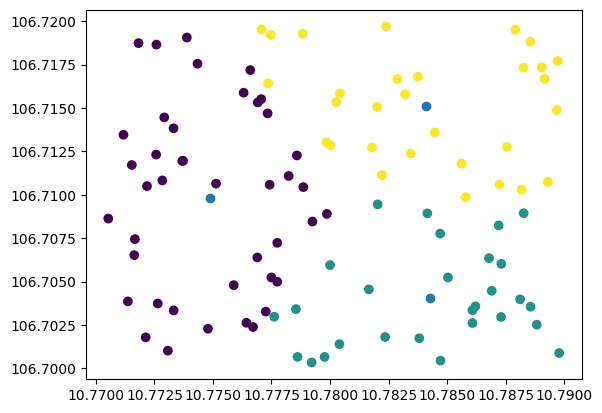

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

data = np.array([[10.77 + np.random.rand()/50, 106.70 + np.random.rand()/50] for _ in range(100)])

kmeans = KMeans(n_clusters=3)
kmeans.fit(data)

plt.scatter(data[:,0], data[:,1], c=kmeans.labels_)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1])

plt.show()


In [ ]:
import folium
import numpy as np

center = [10.776,106.700]

points = np.array([[10.77 + np.random.rand()/100, 106.70 + np.random.rand()/100] for _ in range(100)])

risk = np.random.randint(1, 10, size=100)

m = folium.Map(location=center, zoom_start=13)

for i, p in enumerate(points):
    color = 'red' if risk[i] > 7 else 'orange' if risk[i] > 4 else 'green'
    folium.CircleMarker(location=p, radius=5, color=color).add_to(m)

m


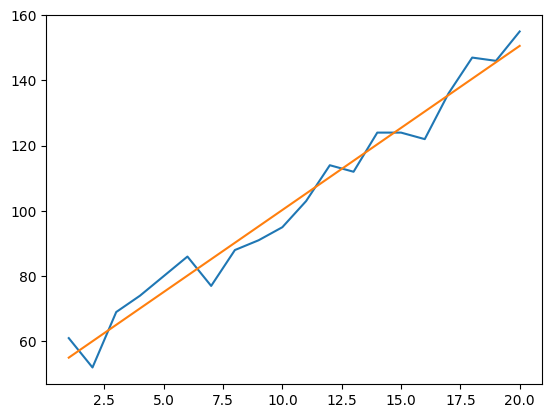

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

time = np.arange(1, 21).reshape(-1,1)
demand = 50 + 5*time.flatten() + np.random.randint(-10,10,20)

model = LinearRegression()
model.fit(time, demand)

pred = model.predict(time)

plt.plot(time, demand)
plt.plot(time, pred)

plt.show()


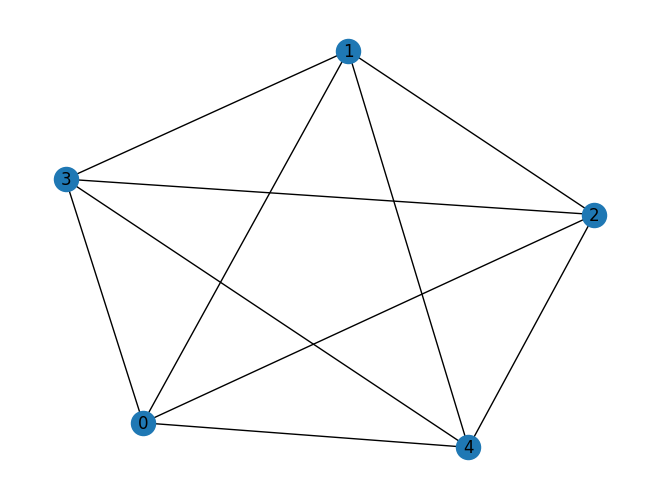

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.complete_graph(5)

pos = nx.spring_layout(G)

path = list(nx.dfs_preorder_nodes(G, source=0))

nx.draw(G, pos, with_labels=True)

plt.show()


In [ ]:
import folium

m = folium.Map(location=[10.776,106.700], zoom_start=13)

folium.Marker([10.78,106.70], popup="Điểm 1").add_to(m)
folium.Marker([10.77,106.69], popup="Điểm 2").add_to(m)

m


In [ ]:
import numpy as np
import folium
import time

m = folium.Map(location=[10.776,106.700], zoom_start=13)

route = [[10.776 + i*0.001,106.700 + i*0.001] for i in range(10)]

for p in route:
    folium.Marker(location=p).add_to(m)

m


In [ ]:
import folium
import numpy as np

m = folium.Map(location=[10.776,106.700], zoom_start=13)

shops = np.array([[10.77 + np.random.rand()/100, 106.70 + np.random.rand()/100] for _ in range(10)])

for s in shops:
    folium.Marker(location=s, popup="Shop").add_to(m)

m
